# DSC 540 Data Preparation
## Final Project - HTML
### David Wederstrandt

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

from io import StringIO
from rapidfuzz import process, fuzz

url = 'https://pmc.ncbi.nlm.nih.gov/articles/PMC6034513/'

In [2]:
# Set up a browser-like User-Agent
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
}

url = 'https://pmc.ncbi.nlm.nih.gov/articles/PMC6034513/'

In [3]:
 # Fetch the HTML content with headers

response = requests.get(url, headers=headers)

html = response.text

In [4]:
tables = pd.read_html(StringIO(html))

In [5]:
print(f"Found {len(tables)} tables.")

Found 4 tables.


In [6]:
for i, table in enumerate(tables):
    print(f'\nTable {i}:\n', table.head())


Table 0:
                              Country  \
                             Country   
                             Country   
0  Low-lower middle income countries   
1                           Colombia   
2                               Iraq   
3                               Peru   
4                          PRC China   

  Lifetime prevalence of PTSD in total sample                     \
                           Unnamed: 1_level_1 Unnamed: 2_level_1   
                                            n                  %   
0                                         394                2.1   
1                                          58                1.8   
2                                         140                2.5   
3                                          22                0.7   
4                                          11                0.3   

                        Trauma exposure                                        \
  Unnamed: 3_level_1 Unnamed: 4_level_1 Un

In [7]:
# Table 2 has the data I am looking for in treatment sector
table3 = tables[2]
table3

Treatment sector Low-lower middle income countries  \
           Treatment sector                Unnamed: 1_level_1   
           Treatment sector                                 %   
0  Specialty mental healthb                               3.2   
1          General medicalc                              14.5   
2              Health cared                              16.8   
3           Human servicese                               7.1   
4                      CAMf                                 –   
5          Non health careg                               7.6   
6            Any treatmenth                              22.8   

                     Upper-middle income countries                     \
  Unnamed: 2_level_1            Unnamed: 3_level_1 Unnamed: 4_level_1   
                S.E.                             %               S.E.   
0                1.9                          11.8                2.7   
1                4.5                          16.8                3.9   
2                4.6                          24.6                4.3   
3                2.2                           2.5                1.2   
4                  –                           4.2                2.1   
5                2.2                           6.6                2.4   
6                5.5                          28.7                4.6   

  High income countries                    All countries combined  \
     Unnamed: 5_level_1 Unnamed: 6_level_1     Unnamed: 7_level_1   
                      %               S.E.                      %   
0                  28.7                1.6                   25.3   
1                  36.0                1.7                   32.4   
2                  49.3                1.8                   44.4   
3                   7.0                0.9                    6.4   
4                   9.9                1.0                    8.8   
5                  14.7                1.2                   13.3   
6                  53.5                1.8                   48.8   

                     Comparison between countriesa  
  Unnamed: 8_level_1 Comparison between countriesa  
                S.E. Comparison between countriesa  
0                1.3         χ2 = 27.8*, p < 0.001  
1                1.5         χ2 = 15.6*, p < 0.001  
2                1.6         χ2 = 23.6*, p < 0.001  
3                0.8           χ2 = 4.3*, p = 0.01  
4                0.9         χ2 = 12.3*, p < 0.001  
5                1.0          χ2 = 6.4*, p < 0.001  
6                1.6         χ2 = 19.9*, p < 0.001

In [8]:
table3.columns

MultiIndex([(                 'Treatment sector', ...),
            ('Low-lower middle income countries', ...),
            ('Low-lower middle income countries', ...),
            (    'Upper-middle income countries', ...),
            (    'Upper-middle income countries', ...),
            (            'High income countries', ...),
            (            'High income countries', ...),
            (           'All countries combined', ...),
            (           'All countries combined', ...),
            (    'Comparison between countriesa', ...)],
           )

## 1. Replace Headers to remove spaces for better readability
All of the column has spaces in their name, I want to clean this up to make them shorter and easier to use.  
The rename() method will take the string before the colon on each line and replace it with the string on the right

In [9]:
# Rename the columns with better, clearer column names

table3.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in table3.columns]
table3

,Treatment sector_Treatment sector_Treatment sector,Low-lower middle income countries_Unnamed: 1_level_1_%,Low-lower middle income countries_Unnamed: 2_level_1_S.E.,Upper-middle income countries_Unnamed: 3_level_1_%,Upper-middle income countries_Unnamed: 4_level_1_S.E.,High income countries_Unnamed: 5_level_1_%,High income countries_Unnamed: 6_level_1_S.E.,All countries combined_Unnamed: 7_level_1_%,All countries combined_Unnamed: 8_level_1_S.E.,Comparison between countriesa_Comparison between countriesa_Comparison between countriesa
0,Specialty mental healthb,3.2,1.9,11.8,2.7,28.7,1.6,25.3,1.3,"χ2 = 27.8*, p < 0.001"
1,General medicalc,14.5,4.5,16.8,3.9,36.0,1.7,32.4,1.5,"χ2 = 15.6*, p < 0.001"
2,Health cared,16.8,4.6,24.6,4.3,49.3,1.8,44.4,1.6,"χ2 = 23.6*, p < 0.001"
3,Human servicese,7.1,2.2,2.5,1.2,7.0,0.9,6.4,0.8,"χ2 = 4.3*, p = 0.01"
4,CAMf,–,–,4.2,2.1,9.9,1.0,8.8,0.9,"χ2 = 12.3*, p < 0.001"
5,Non health careg,7.6,2.2,6.6,2.4,14.7,1.2,13.3,1.0,"χ2 = 6.4*, p < 0.001"
6,Any treatmenth,22.8,5.5,28.7,4.6,53.5,1.8,48.8,1.6,"χ2 = 19.9*, p < 0.001"


In [10]:
table3.columns = [
    'Treatment_Sector',
    'Low_LMI_Ctry_%', 'Low_LMI_Ctry_SE',
    'Upper_Mid_Income_Ctry_%', 'Upper_Mid_Income_Ctry_SE',
    'High_Income_Ctry_%', 'High_Income_Ctry_SE',
    'All_Countries_%', 'All_Countries_SE',
    'Country_Comparison'
]

In [11]:
table3.columns = [col.replace('\n', ' ').replace('*', '').replace('a', '').strip() for col in table3.columns]

| Column Name | Description  |
| --- | ---|
| Treatment_Sector | The Category of Treatment |
| Low_LMI_Ctry_% | Low-lower middle income countries Percentage |
| Low_LMI_Ctry_SE | Low-lower middle income countries Standard Error |
| Upper_Mid_Income_Ctry_% | Upper-middle income countries Percentage |
| Upper_Mid_Income_Ctry_SE | Upper-middle income countries Standard Error |
| High_Income_Ctry_% | High income countries Percentage |
| High_Income_Ctry_SE| High income countries Standard Error |
| All_Countries_% | All countries combined income countries Percentage |
| All_Countries_SE | All countries combined income countries Standard Error |
| Country_Comprison | Comparison between countries |

In [12]:
table3

,Tretment_Sector,Low_LMI_Ctry_%,Low_LMI_Ctry_SE,Upper_Mid_Income_Ctry_%,Upper_Mid_Income_Ctry_SE,High_Income_Ctry_%,High_Income_Ctry_SE,All_Countries_%,All_Countries_SE,Country_Comprison
0,Specialty mental healthb,3.2,1.9,11.8,2.7,28.7,1.6,25.3,1.3,"χ2 = 27.8*, p < 0.001"
1,General medicalc,14.5,4.5,16.8,3.9,36.0,1.7,32.4,1.5,"χ2 = 15.6*, p < 0.001"
2,Health cared,16.8,4.6,24.6,4.3,49.3,1.8,44.4,1.6,"χ2 = 23.6*, p < 0.001"
3,Human servicese,7.1,2.2,2.5,1.2,7.0,0.9,6.4,0.8,"χ2 = 4.3*, p = 0.01"
4,CAMf,–,–,4.2,2.1,9.9,1.0,8.8,0.9,"χ2 = 12.3*, p < 0.001"
5,Non health careg,7.6,2.2,6.6,2.4,14.7,1.2,13.3,1.0,"χ2 = 6.4*, p < 0.001"
6,Any treatmenth,22.8,5.5,28.7,4.6,53.5,1.8,48.8,1.6,"χ2 = 19.9*, p < 0.001"


## 2. Format data into a more readable format
float or NaN for errors

In [13]:
# Function to convert to Int64, handling potential errors
def safe_convert_to_float64(series):
    try:
        return series.astype('Float64')  # Nullable float dtype (supports NaN)
    except (ValueError, TypeError):
        return pd.to_numeric(series, errors='coerce').astype('Float64')

In [14]:
# Convert 
table3.dtypes

Tretment_Sector              object
Low_LMI_Ctry_%               object
Low_LMI_Ctry_SE              object
Upper_Mid_Income_Ctry_%     float64
Upper_Mid_Income_Ctry_SE    float64
High_Income_Ctry_%          float64
High_Income_Ctry_SE         float64
All_Countries_%             float64
All_Countries_SE            float64
Country_Comprison            object
dtype: object

In [15]:
# Convert the columns to float and handle errors
table3_cleaned = table3.copy()

# Apply to relevant columns
for col in ['Low_LMI_Ctry_%', 'Low_LMI_Ctry_SE', 'Upper_Mid_Income_Ctry_%', 'Upper_Mid_Income_Ctry_SE',
            'High_Income_Ctry_%', 'High_Income_Ctry_SE', 'All_Countries_%', 'All_Countries_SE']:
    table3_cleaned[col] = safe_convert_to_float64(table3_cleaned[col])

In [16]:
table3_cleaned

,Tretment_Sector,Low_LMI_Ctry_%,Low_LMI_Ctry_SE,Upper_Mid_Income_Ctry_%,Upper_Mid_Income_Ctry_SE,High_Income_Ctry_%,High_Income_Ctry_SE,All_Countries_%,All_Countries_SE,Country_Comprison
0,Specialty mental healthb,3.2,1.9,11.8,2.7,28.7,1.6,25.3,1.3,"χ2 = 27.8*, p < 0.001"
1,General medicalc,14.5,4.5,16.8,3.9,36.0,1.7,32.4,1.5,"χ2 = 15.6*, p < 0.001"
2,Health cared,16.8,4.6,24.6,4.3,49.3,1.8,44.4,1.6,"χ2 = 23.6*, p < 0.001"
3,Human servicese,7.1,2.2,2.5,1.2,7.0,0.9,6.4,0.8,"χ2 = 4.3*, p = 0.01"
4,CAMf,<NA>,<NA>,4.2,2.1,9.9,1.0,8.8,0.9,"χ2 = 12.3*, p < 0.001"
5,Non health careg,7.6,2.2,6.6,2.4,14.7,1.2,13.3,1.0,"χ2 = 6.4*, p < 0.001"
6,Any treatmenth,22.8,5.5,28.7,4.6,53.5,1.8,48.8,1.6,"χ2 = 19.9*, p < 0.001"


## 3. Identify Outliers and Bad Data

Create a boxplot to vizualize any outliers

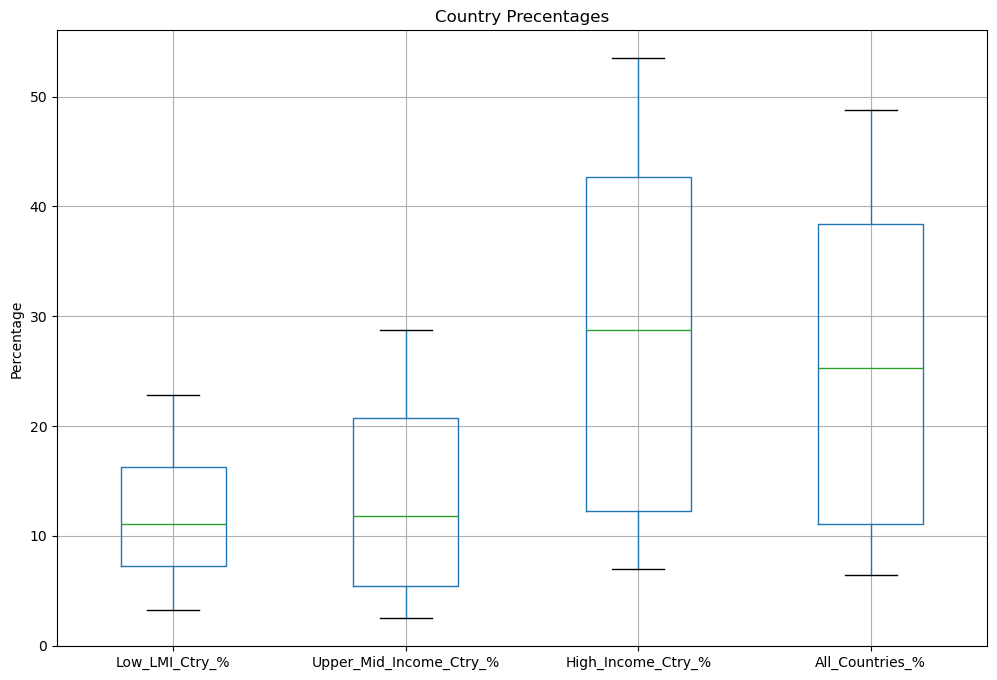

In [17]:
plt.figure(figsize=(12,8))
table3_cleaned[['Low_LMI_Ctry_%', 'Upper_Mid_Income_Ctry_%', 'High_Income_Ctry_%', 'All_Countries_%']].boxplot()
plt.title("Country Precentages")
plt.ylabel('Percentage')
plt.show()

In [18]:
# Find the outliers
q1 = table3_cleaned['Low_LMI_Ctry_%'].quantile(0.25)
q3 = table3_cleaned['Low_LMI_Ctry_%'].quantile(0.75)

# IQR the middle 50%
iqr = q3 - q1

# outliers are any points outside of  +- 1.5 * iqr for q3 and q1 respectively
outliers = table3_cleaned[(table3_cleaned['Low_LMI_Ctry_%'] < q1 - 1.5 * iqr) | (table3_cleaned['Low_LMI_Ctry_%'] > q3 + 1.5 * iqr)]
print(outliers)    

Empty DataFrame
Columns: [Tretment_Sector, Low_LMI_Ctry_%, Low_LMI_Ctry_SE, Upper_Mid_Income_Ctry_%, Upper_Mid_Income_Ctry_SE, High_Income_Ctry_%, High_Income_Ctry_SE, All_Countries_%, All_Countries_SE, Country_Comprison]
Index: []


Not identifing any outliers in this data

## 4. Find Duplicates and Handle them

In [19]:
# find duplicates
duplicates = table3_cleaned[table3_cleaned.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Tretment_Sector, Low_LMI_Ctry_%, Low_LMI_Ctry_SE, Upper_Mid_Income_Ctry_%, Upper_Mid_Income_Ctry_SE, High_Income_Ctry_%, High_Income_Ctry_SE, All_Countries_%, All_Countries_SE, Country_Comprison]
Index: []


I am not seeing any duplicates in this data. If there were, I could use .drop_duplicates()  

# 5. Fix Casting or Inconsistencies in Values

Standardize the text in columns

In [20]:
# Create a for loop that standardizes casting and strips whitespace for all object columns

for col in table3_cleaned.select_dtypes(include=['object']).columns:
    table3_cleaned[col] = table3_cleaned[col].str.strip().str.title()

table3_cleaned

,Tretment_Sector,Low_LMI_Ctry_%,Low_LMI_Ctry_SE,Upper_Mid_Income_Ctry_%,Upper_Mid_Income_Ctry_SE,High_Income_Ctry_%,High_Income_Ctry_SE,All_Countries_%,All_Countries_SE,Country_Comprison
0,Specialty Mental Healthb,3.2,1.9,11.8,2.7,28.7,1.6,25.3,1.3,"Χ2 = 27.8*, P < 0.001"
1,General Medicalc,14.5,4.5,16.8,3.9,36.0,1.7,32.4,1.5,"Χ2 = 15.6*, P < 0.001"
2,Health Cared,16.8,4.6,24.6,4.3,49.3,1.8,44.4,1.6,"Χ2 = 23.6*, P < 0.001"
3,Human Servicese,7.1,2.2,2.5,1.2,7.0,0.9,6.4,0.8,"Χ2 = 4.3*, P = 0.01"
4,Camf,<NA>,<NA>,4.2,2.1,9.9,1.0,8.8,0.9,"Χ2 = 12.3*, P < 0.001"
5,Non Health Careg,7.6,2.2,6.6,2.4,14.7,1.2,13.3,1.0,"Χ2 = 6.4*, P < 0.001"
6,Any Treatmenth,22.8,5.5,28.7,4.6,53.5,1.8,48.8,1.6,"Χ2 = 19.9*, P < 0.001"


## 6. Conduct Fuzzy Matching

Use rapidstring to identify and strings that may be similar

In [21]:
# Conduct fuzzy matching on the object column, which is Treatment_Sector

ref_dict = {'Treatment_Sector': [
    'Primary Care', 'Mental Health', 'Communtiy', 'Other']
           }

In [22]:
# Create a for loop to look for matches (I only have one object column, but I need the practice. 
for col in table3_cleaned.select_dtypes(['object']).columns:
    if col in ref_dict:
        table3_cleaned[col + '_Matched'] = table3_cleaned[col].apply(
            lambda x: process.extractOne(x, ref_dict[col], score=fuzz.ratio)[0] if pd.notnull(x) else x
        )

In [23]:
table3_cleaned.reset_index()
table3_cleaned.to_csv('data/html_data.csv')

## Project Summary


In this project, I performed extensive data wrangling on PTSD treatment outcome data sourced from published research, including renaming columns, formatting data types, identifying and handling outliers and duplicates, correcting inconsistent values, and applying fuzzy matching to categorical fields. These changes were made to improve data quality and facilitate analysis, but they also introduce ethical considerations. Since the data relates to health outcomes, it may be subject to legal and regulatory guidelines such as HIPAA or other privacy standards, even though the dataset appears to be aggregated and de-identified. Risks include the potential for misrepresentation or loss of nuance due to data cleaning steps, such as removing outliers or standardizing categories, which could inadvertently bias results or obscure important context. Assumptions were made regarding the accuracy of source data and the appropriateness of transformations, such as treating certain values as errors or inferring correct categories through fuzzy matching. The data was sourced from a reputable, peer-reviewed publication, supporting its credibility, and was acquired in an ethical manner for academic analysis. To mitigate ethical risks, I would document all transformations, ensure transparency in reporting, avoid over-cleaning that could distort findings, and consult relevant guidelines to confirm compliance with privacy and data use standards.